# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan
## Jaya Jaya Institut — Sistem Deteksi Dini Risiko Dropout Mahasiswa

- **Nama:** *Tegar Arifin Prasetyo*
- **Email:** *arifintegar12@gmail.com*
- **ID Dicoding:** *tegar_arifin_umpr*

---

## 1. Business Understanding

Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000. Meskipun
memiliki reputasi baik, institusi ini menghadapi angka **dropout** yang tinggi. Dropout merugikan
dua pihak sekaligus: mahasiswa kehilangan waktu dan biaya tanpa memperoleh gelar, sementara
institusi kehilangan pendapatan, mengalami penurunan tingkat kelulusan, dan berisiko turun
peringkat akreditasi.

### 1.1 Permasalahan Bisnis

1. Belum diketahui **seberapa besar** dan **di mana** konsentrasi masalah dropout terjadi
   (program studi, jalur masuk, kelompok usia, kondisi finansial).
2. Belum diketahui **faktor-faktor apa** yang paling menentukan seorang mahasiswa akan dropout.
3. Belum ada mekanisme untuk **mendeteksi risiko dropout sedini mungkin**, sehingga intervensi
   bimbingan baru diberikan setelah mahasiswa benar-benar mengundurkan diri.
4. Manajemen belum memiliki **alat monitoring** yang mudah dipahami untuk memantau performa siswa
   secara berkelanjutan.

### 1.2 Cakupan Proyek

1. Data understanding dan exploratory data analysis (EDA) atas 4.424 record mahasiswa.
2. Data preparation: definisi target, encoding, scaling, dan pemisahan data latih/uji.
3. Modeling: membandingkan tiga algoritma klasifikasi untuk memprediksi risiko dropout.
4. Evaluation: pemilihan model terbaik, penyetelan *threshold*, dan analisis feature importance.
5. Membangun **business dashboard** untuk monitoring performa siswa.
6. Men-*deploy* **prototype machine learning** berbasis Streamlit ke Streamlit Community Cloud.
7. Menyusun **rekomendasi action items** bagi manajemen Jaya Jaya Institut.

### 1.3 Persiapan

**Sumber data:** [Students' Performance — Dicoding Academy](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance)

**Setup environment:**

```bash
python -m venv venv
source venv/bin/activate      # Windows: venv\Scripts\activate
pip install -r requirements.txt
```

## 2. Data Understanding

In [ ]:
import warnings, json, io
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, precision_recall_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PAL = ["#2E86AB", "#E4572E", "#F3A712"]
RANDOM_STATE = 42

In [ ]:
URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
try:
    df = pd.read_csv("data.csv", sep=";")
except FileNotFoundError:
    df = pd.read_csv(URL, sep=";")

df.columns = [c.strip().replace("\ufeff", "") for c in df.columns]
print("Dimensi dataset :", df.shape)
df.head()

Dimensi dataset : (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [ ]:
print("Jumlah nilai kosong :", df.isna().sum().sum())
print("Jumlah baris duplikat:", df.duplicated().sum())
print("\nDistribusi target:")
print(df["Status"].value_counts())
print()
print((df["Status"].value_counts(normalize=True) * 100).round(2))

Jumlah nilai kosong : 0
Jumlah baris duplikat: 0

Distribusi target:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


Dataset terdiri atas **4.424 baris** dan **37 kolom**, **tanpa nilai kosong maupun duplikat**,
sehingga proses pembersihan data relatif ringan. Kolom target `Status` memiliki tiga kelas:
`Graduate`, `Dropout`, dan `Enrolled`.

**Keputusan pemodelan.** Kebutuhan bisnis Jaya Jaya Institut adalah *"mendeteksi secepat mungkin
siswa yang mungkin akan melakukan dropout"*. Karena itu target dirumuskan ulang menjadi masalah
**klasifikasi biner**: `Dropout` (kelas positif) versus `Non-Dropout` (gabungan `Graduate` dan
`Enrolled`). Alasannya:

1. Kelas `Enrolled` adalah status *sementara* — mahasiswa masih berjalan dan belum diketahui
   hasil akhirnya, sehingga bukan lawan yang setara bagi `Graduate`.
2. Metrik bisnis yang relevan (recall terhadap dropout, biaya *false negative*) hanya bermakna
   pada formulasi biner.
3. Keluaran berupa satu **skor risiko 0–100** jauh lebih mudah dioperasikan oleh bagian
   kemahasiswaan dibanding tiga probabilitas kelas.

In [ ]:
df["Dropout"] = (df["Status"] == "Dropout").astype(int)
print(f"Proporsi dropout: {df['Dropout'].mean()*100:.2f}%")

CAT = ["Marital_status", "Application_mode", "Course", "Daytime_evening_attendance",
       "Previous_qualification", "Nacionality", "Mothers_qualification", "Fathers_qualification",
       "Mothers_occupation", "Fathers_occupation", "Displaced", "Educational_special_needs",
       "Debtor", "Tuition_fees_up_to_date", "Gender", "Scholarship_holder", "International"]
NUM = [c for c in df.columns if c not in CAT + ["Status", "Dropout"]]

print(f"Fitur kategorikal : {len(CAT)}")
print(f"Fitur numerik     : {len(NUM)}")

Proporsi dropout: 32.12%
Fitur kategorikal : 17
Fitur numerik     : 19


### Deskripsi Fitur

| Kelompok | Fitur | Keterangan |
|---|---|---|
| Demografi | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced` | Karakteristik pribadi mahasiswa |
| Latar belakang keluarga | `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, `Fathers_occupation` | Pendidikan & pekerjaan orang tua |
| Pendaftaran | `Application_mode`, `Application_order`, `Course`, `Daytime_evening_attendance`, `Previous_qualification`, `Previous_qualification_grade`, `Admission_grade` | Jalur & kualifikasi saat masuk |
| Finansial | `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder` | Kondisi keuangan mahasiswa |
| Akademik | `Curricular_units_1st/2nd_sem_*` (credited, enrolled, evaluations, approved, grade, without_evaluations) | Performa dua semester pertama |
| Makroekonomi | `Unemployment_rate`, `Inflation_rate`, `GDP` | Kondisi ekonomi saat studi berlangsung |

## 3. Exploratory Data Analysis

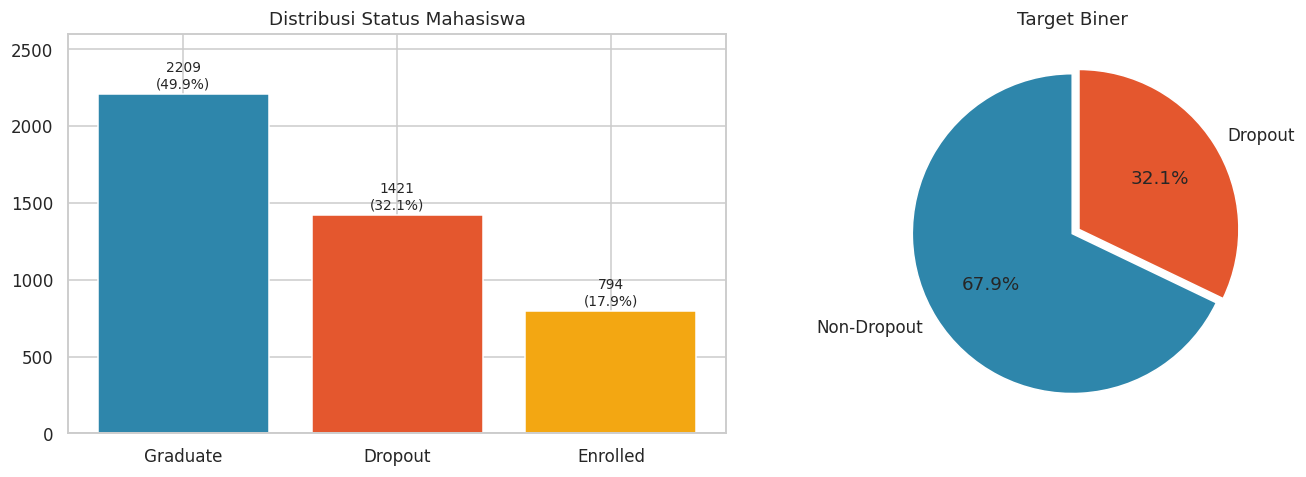

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

s = df["Status"].value_counts()
ax[0].bar(s.index, s.values, color=[PAL[0], PAL[1], PAL[2]])
for i, v in enumerate(s.values):
    ax[0].text(i, v + 40, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
ax[0].set_title("Distribusi Status Mahasiswa"); ax[0].set_ylim(0, 2600)

b = df["Dropout"].value_counts()
ax[1].pie(b.values, labels=["Non-Dropout", "Dropout"], autopct="%1.1f%%",
          colors=[PAL[0], PAL[1]], explode=(0, 0.05), startangle=90)
ax[1].set_title("Target Biner")
plt.tight_layout(); plt.show()

**Insight.** Sebanyak **32,1%** mahasiswa berstatus dropout — hampir sepertiga populasi. Angka ini
sangat tinggi untuk sebuah perguruan tinggi dan mengonfirmasi urgensi masalah. Ketidakseimbangan
kelas tergolong moderat (68:32), sehingga masih dapat ditangani dengan `class_weight` dan
penyetelan threshold tanpa perlu *oversampling*.

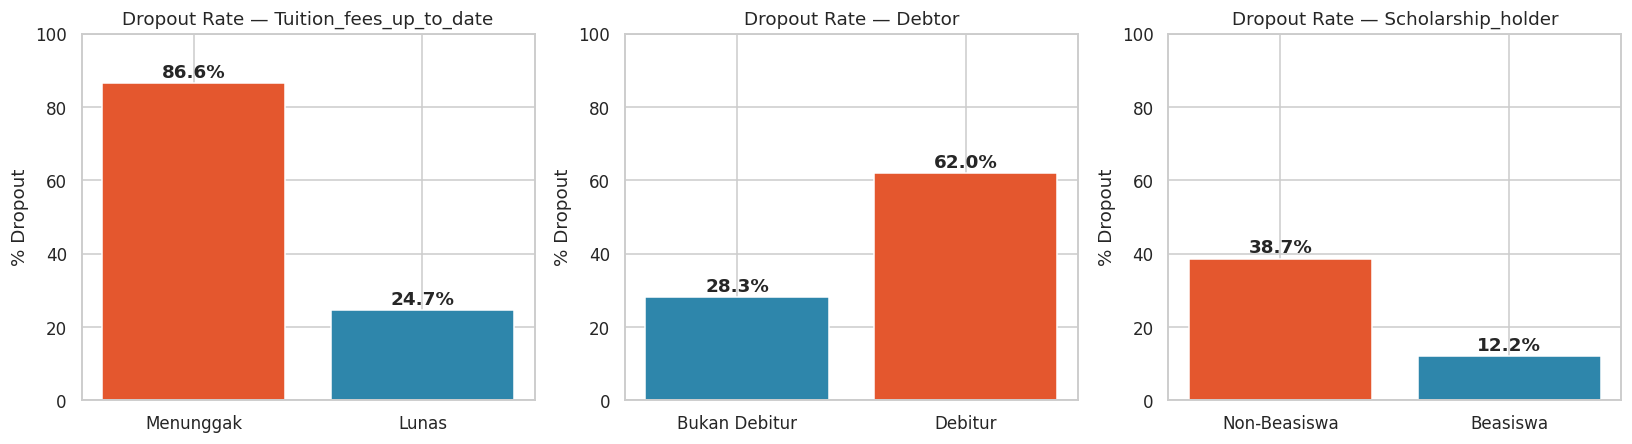

In [ ]:
fin = ["Tuition_fees_up_to_date", "Debtor", "Scholarship_holder"]
lbl = {"Tuition_fees_up_to_date": ["Menunggak", "Lunas"],
       "Debtor": ["Bukan Debitur", "Debitur"],
       "Scholarship_holder": ["Non-Beasiswa", "Beasiswa"]}

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, c in enumerate(fin):
    r = df.groupby(c)["Dropout"].mean() * 100
    ax[i].bar(lbl[c], r.values, color=[PAL[1], PAL[0]] if c != "Debtor" else [PAL[0], PAL[1]])
    for j, v in enumerate(r.values):
        ax[i].text(j, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")
    ax[i].set_title(f"Dropout Rate — {c}"); ax[i].set_ylabel("% Dropout"); ax[i].set_ylim(0, 100)
plt.tight_layout(); plt.show()

**Insight — faktor finansial sangat dominan.**

- Mahasiswa yang **menunggak UKT** memiliki tingkat dropout **86,6%**, dibanding **24,7%** pada
  yang lunas — selisih lebih dari 60 poin persentase.
- Mahasiswa berstatus **debitur** dropout pada tingkat **62,0%** vs **28,3%**.
- **Penerima beasiswa** justru jauh lebih aman: **12,2%** vs **38,7%**.

Ini menandakan bahwa masalah dropout di Jaya Jaya Institut bukan semata masalah akademik,
melainkan sangat lekat dengan **kemampuan membayar**.

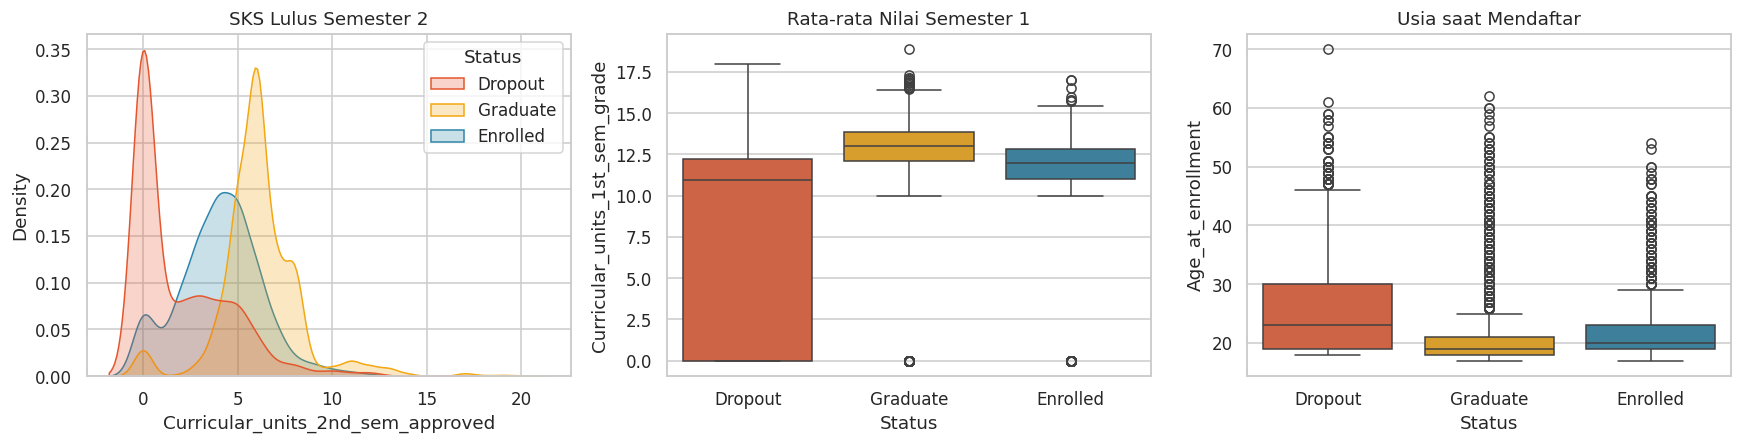

,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade,Admission_grade,Age_at_enrollment
Status,,,,,,
Dropout,2.55,1.94,7.26,5.90,124.96,26.07
Enrolled,4.32,4.06,11.13,11.12,125.53,22.37
Graduate,6.23,6.18,12.64,12.70,128.79,21.78


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.kdeplot(data=df, x="Curricular_units_2nd_sem_approved", hue="Status", fill=True,
            common_norm=False, palette=[PAL[1], PAL[2], PAL[0]], ax=ax[0])
ax[0].set_title("SKS Lulus Semester 2")

sns.boxplot(data=df, x="Status", y="Curricular_units_1st_sem_grade",
            palette=[PAL[1], PAL[2], PAL[0]], ax=ax[1])
ax[1].set_title("Rata-rata Nilai Semester 1")

sns.boxplot(data=df, x="Status", y="Age_at_enrollment",
            palette=[PAL[1], PAL[2], PAL[0]], ax=ax[2])
ax[2].set_title("Usia saat Mendaftar")
plt.tight_layout(); plt.show()

df.groupby("Status")[["Curricular_units_1st_sem_approved", "Curricular_units_2nd_sem_approved",
                      "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_grade",
                      "Admission_grade", "Age_at_enrollment"]].mean().round(2)

**Insight — performa akademik dua semester pertama adalah sinyal paling awal.**

Mahasiswa dropout rata-rata hanya meluluskan **2,55 mata kuliah** di semester 1 dan **1,94** di
semester 2, dibandingkan lulusan yang meluluskan **6,23** dan **6,18**. Terlihat pula penumpukan
besar pada nilai 0 untuk kelompok dropout — indikasi mahasiswa yang berhenti aktif sejak awal.
Nilai ujian masuk (`Admission_grade`) hanya berbeda tipis antar kelompok (124,96 vs 128,79), artinya **kemampuan awal
bukan penentu utama**; yang menentukan adalah apa yang terjadi *setelah* mahasiswa masuk.
Mahasiswa dropout juga rata-rata mendaftar pada usia lebih tua (**26,1** vs **21,9** tahun).

,mean,count
Kategori_Performa,,
Kritis (<25%),81.6,882
Rendah (25-50%),70.0,333
Sedang (50-75%),40.4,634
Baik (>75%),8.2,2575


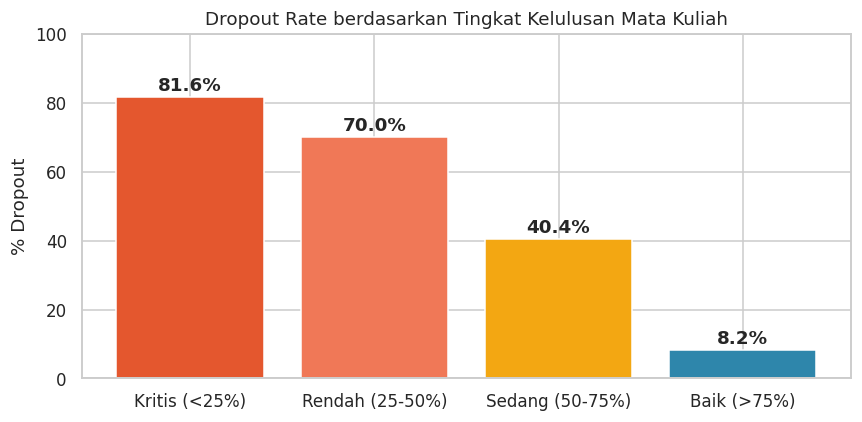

In [ ]:
tot = df["Curricular_units_1st_sem_enrolled"] + df["Curricular_units_2nd_sem_enrolled"]
apr = df["Curricular_units_1st_sem_approved"] + df["Curricular_units_2nd_sem_approved"]
df["Approval_Rate"] = np.where(tot > 0, apr / tot * 100, 0)
df["Kategori_Performa"] = pd.cut(df["Approval_Rate"], [-1, 25, 50, 75, 100],
                                 labels=["Kritis (<25%)", "Rendah (25-50%)",
                                         "Sedang (50-75%)", "Baik (>75%)"])

perf = df.groupby("Kategori_Performa", observed=True)["Dropout"].agg(["mean", "count"])
perf["mean"] = (perf["mean"] * 100).round(1)
display(perf)

plt.figure(figsize=(8, 4))
plt.bar(perf.index.astype(str), perf["mean"], color=[PAL[1], "#F07857", PAL[2], PAL[0]])
for i, v in enumerate(perf["mean"]):
    plt.text(i, v + 2, f"{v}%", ha="center", fontweight="bold")
plt.title("Dropout Rate berdasarkan Tingkat Kelulusan Mata Kuliah")
plt.ylabel("% Dropout"); plt.ylim(0, 100); plt.tight_layout(); plt.show()

**Insight.** Tingkat kelulusan mata kuliah adalah pembeda paling tajam: kelompok **Kritis (<25%)**
memiliki dropout rate **81,6%**, sementara kelompok **Baik (>75%)** hanya **8,2%**. Metrik
sederhana ini saja sudah dapat dipakai sebagai *rule of thumb* penyaringan oleh dosen wali.

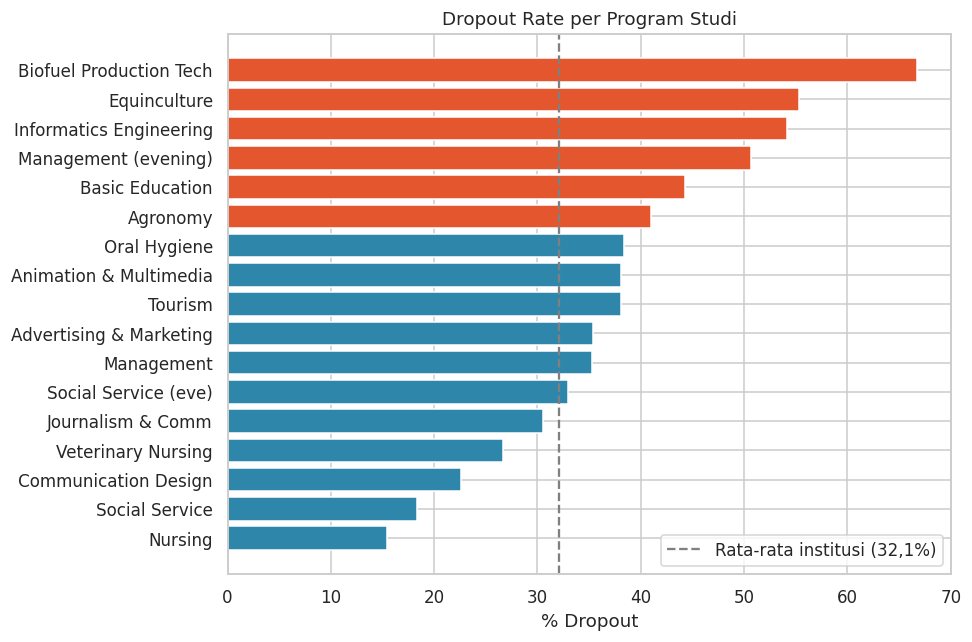

,mean,count
Program_Studi,,
Biofuel Production Tech,66.7,12
Equinculture,55.3,141
Informatics Engineering,54.1,170
Management (evening),50.7,268
Basic Education,44.3,192
Agronomy,41.0,210


In [ ]:
COURSE = {33: "Biofuel Production Tech", 171: "Animation & Multimedia", 8014: "Social Service (eve)",
          9003: "Agronomy", 9070: "Communication Design", 9085: "Veterinary Nursing",
          9119: "Informatics Engineering", 9130: "Equinculture", 9147: "Management",
          9238: "Social Service", 9254: "Tourism", 9500: "Nursing", 9556: "Oral Hygiene",
          9670: "Advertising & Marketing", 9773: "Journalism & Comm", 9853: "Basic Education",
          9991: "Management (evening)"}
df["Program_Studi"] = df["Course"].map(COURSE)

g = df.groupby("Program_Studi")["Dropout"].agg(["mean", "count"]).sort_values("mean")
g["mean"] = (g["mean"] * 100).round(1)

plt.figure(figsize=(9, 6))
plt.barh(g.index, g["mean"], color=[PAL[1] if v > 40 else PAL[0] for v in g["mean"]])
plt.axvline(32.1, ls="--", color="gray", label="Rata-rata institusi (32,1%)")
plt.title("Dropout Rate per Program Studi"); plt.xlabel("% Dropout"); plt.legend()
plt.tight_layout(); plt.show()
g.sort_values("mean", ascending=False).head(6)

**Insight.** Risiko dropout sangat tidak merata antar program studi. **Biofuel Production
Technologies (66,7%)**, **Equinculture (55,3%)**, **Informatics Engineering (54,1%)**, dan
**Management kelas malam (50,7%)** berada jauh di atas rata-rata institusi. Sebaliknya
**Nursing** termasuk paling aman. Ini berarti intervensi tidak perlu diseragamkan — sumber daya
bimbingan sebaiknya dikonsentrasikan pada prodi-prodi berisiko tinggi.

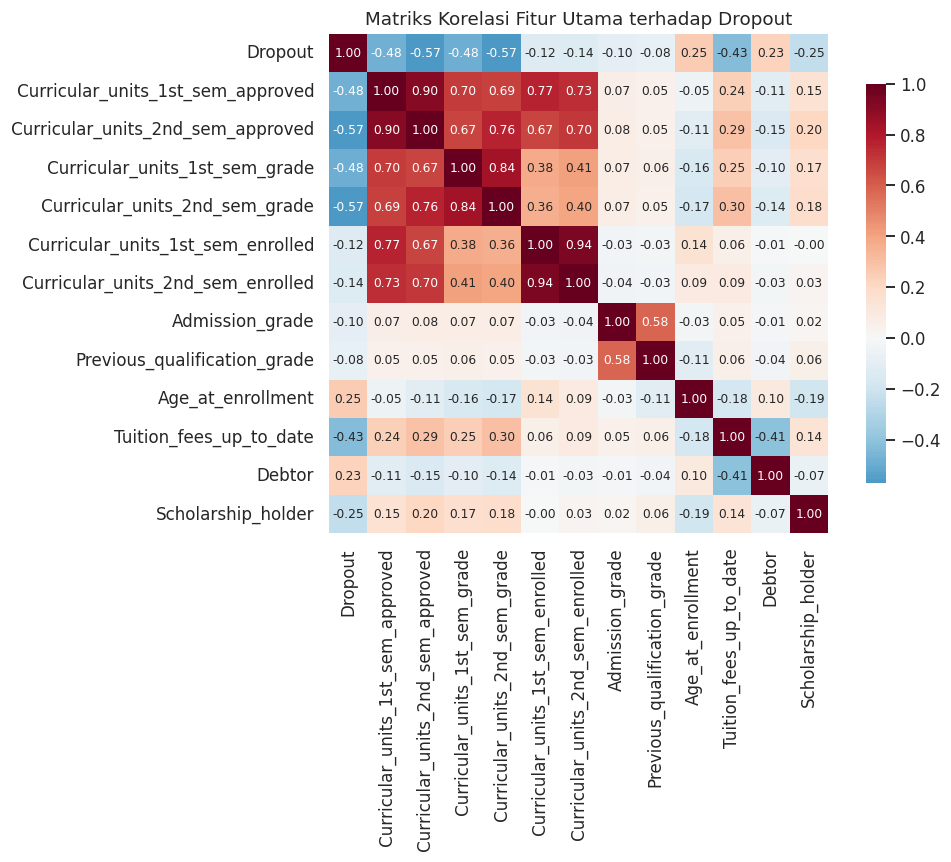

In [ ]:
num_corr = ["Dropout", "Curricular_units_1st_sem_approved", "Curricular_units_2nd_sem_approved",
            "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_grade",
            "Curricular_units_1st_sem_enrolled", "Curricular_units_2nd_sem_enrolled",
            "Admission_grade", "Previous_qualification_grade", "Age_at_enrollment",
            "Tuition_fees_up_to_date", "Debtor", "Scholarship_holder"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_corr].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Utama terhadap Dropout")
plt.tight_layout(); plt.show()

**Insight.** Korelasi terkuat dengan dropout dimiliki oleh `Curricular_units_2nd_sem_approved`
(**-0,57**) dan `Curricular_units_1st_sem_approved` (**-0,48**) — semakin banyak mata kuliah yang
lulus, semakin kecil risiko dropout. `Tuition_fees_up_to_date` juga berkorelasi kuat negatif
(**-0,43**). Perlu dicatat bahwa fitur semester 1 dan 2 saling berkorelasi tinggi (multikolinearitas),
yang tidak mengganggu model berbasis pohon namun perlu diingat saat menafsirkan koefisien
regresi logistik.

## 4. Data Preparation

Langkah persiapan data:

1. **Definisi target** — `Dropout = 1` jika `Status == "Dropout"`, selain itu `0`.
2. **Pembagian fitur** — 17 fitur kategorikal (kode nominal) dan 19 fitur numerik.
3. **Split data** — 80% latih / 20% uji, *stratified* agar proporsi dropout terjaga.
4. **Preprocessing pipeline** — `StandardScaler` untuk fitur numerik dan `OneHotEncoder`
   (`handle_unknown="ignore"`, `min_frequency=10`) untuk fitur kategorikal. Seluruh transformasi
   dibungkus dalam `Pipeline` sehingga *fit* hanya terjadi pada data latih dan **tidak ada
   kebocoran data** ke data uji.

In [ ]:
X = df[CAT + NUM]
y = df["Dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Data latih : {X_train.shape} | dropout {y_train.mean()*100:.1f}%")
print(f"Data uji   : {X_test.shape} | dropout {y_test.mean()*100:.1f}%")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False), CAT),
])
preprocessor.fit(X_train)
print("Jumlah fitur setelah encoding:", preprocessor.transform(X_train.head()).shape[1])

Data latih : (3539, 36) | dropout 32.1%
Data uji   : (885, 36) | dropout 32.1%
Jumlah fitur setelah encoding: 139


## 5. Modeling

Tiga algoritma dibandingkan, masing-masing dibungkus dalam pipeline yang sama:

| Model | Alasan dipilih |
|---|---|
| **Logistic Regression** | *Baseline* linier yang mudah diinterpretasi |
| **Random Forest** | Ensemble bagging, tahan outlier & interaksi non-linier |
| **HistGradientBoosting** | Ensemble boosting, umumnya terbaik untuk data tabular |

Evaluasi menggunakan **5-fold Stratified Cross Validation** pada data latih (ROC-AUC dan F1),
lalu diverifikasi pada data uji yang belum pernah dilihat model.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                            class_weight="balanced_subsample",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, learning_rate=0.08, max_iter=400, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15),
}

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}

for name, m in models.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", m)])
    auc_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    f1_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({"Model": name,
                 "CV ROC-AUC": auc_cv.mean(), "CV F1": f1_cv.mean(),
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, proba),
                 "PR-AUC": average_precision_score(y_test, proba)})
    fitted[name] = pipe
    print(f"selesai: {name}")

comparison = pd.DataFrame(rows).round(4)
comparison

selesai: Logistic Regression


selesai: Random Forest


selesai: HistGradientBoosting


,Model,CV ROC-AUC,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9208,0.7854,0.8836,0.8027,0.8451,0.8233,0.9324,0.9028
1,Random Forest,0.9162,0.7896,0.8768,0.8405,0.7606,0.7985,0.9296,0.8990
2,HistGradientBoosting,0.9138,0.7803,0.8881,0.8776,0.7570,0.8129,0.9341,0.9014


Ketiga model memberikan performa yang berdekatan, namun **HistGradientBoosting** unggul pada
ROC-AUC uji (**0,934**) sekaligus akurasi tertinggi. Model inilah yang dipilih untuk produksi.

In [ ]:
best_name = comparison.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = fitted[best_name]
print("Model terbaik:", best_name)

Model terbaik: HistGradientBoosting


## 6. Evaluation

### 6.1 Penyetelan Threshold

Ambang default 0,5 tidak optimal untuk kasus ini. Dalam konteks bisnis, **false negative**
(mahasiswa berisiko yang lolos deteksi) jauh lebih mahal daripada **false positive** (mahasiswa
aman yang ikut bimbingan tambahan). Threshold dicari dari **prediksi out-of-fold pada data latih**
— bukan dari data uji — agar tidak terjadi kebocoran informasi.

In [ ]:
oof = cross_val_predict(Pipeline([("pre", preprocessor), ("clf", models[best_name])]),
                        X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
THRESHOLD = float(thr[int(np.nanargmax(f1s[:-1]))])
print(f"Threshold optimal (dari OOF data latih): {THRESHOLD:.3f}")

proba_test = best_model.predict_proba(X_test)[:, 1]
tabel = []
for t in [0.30, 0.35, 0.40, THRESHOLD, 0.50, 0.60]:
    p = (proba_test >= t).astype(int)
    tabel.append({"Threshold": round(t, 3), "Accuracy": accuracy_score(y_test, p),
                  "Precision": precision_score(y_test, p), "Recall": recall_score(y_test, p),
                  "F1": f1_score(y_test, p)})
pd.DataFrame(tabel).round(4)

Threshold optimal (dari OOF data latih): 0.447


,Threshold,Accuracy,Precision,Recall,F1
0,0.300,0.8644,0.7645,0.8345,0.7980
1,0.350,0.8802,0.8069,0.8239,0.8153
2,0.400,0.8904,0.8400,0.8134,0.8265
3,0.447,0.8972,0.8697,0.7993,0.8330
4,0.500,0.8881,0.8776,0.7570,0.8129
5,0.600,0.8825,0.9091,0.7042,0.7937


              precision    recall  f1-score   support

 Non-Dropout      0.909     0.943     0.926       601
     Dropout      0.870     0.799     0.833       284

    accuracy                          0.897       885
   macro avg      0.889     0.871     0.879       885
weighted avg      0.896     0.897     0.896       885



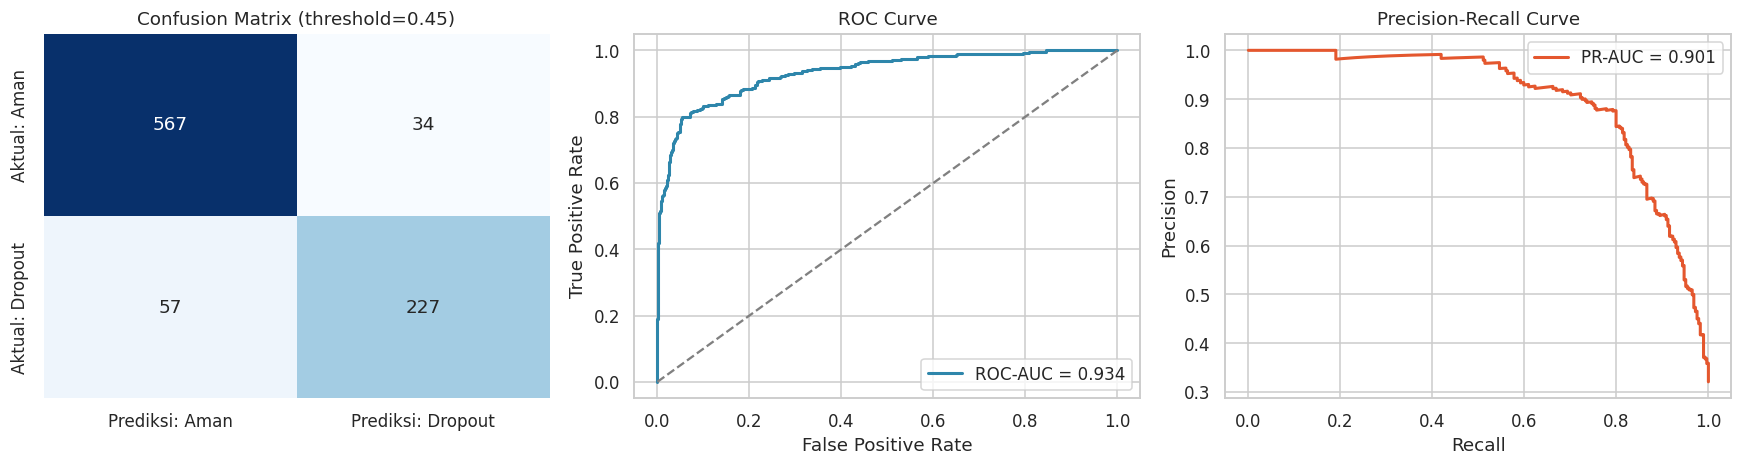

In [ ]:
y_pred = (proba_test >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred, target_names=["Non-Dropout", "Dropout"], digits=3))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["Prediksi: Aman", "Prediksi: Dropout"],
            yticklabels=["Aktual: Aman", "Aktual: Dropout"])
ax[0].set_title(f"Confusion Matrix (threshold={THRESHOLD:.2f})")

fpr, tpr, _ = roc_curve(y_test, proba_test)
ax[1].plot(fpr, tpr, color=PAL[0], lw=2, label=f"ROC-AUC = {roc_auc_score(y_test, proba_test):.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve"); ax[1].legend()

pr_, rc_, _ = precision_recall_curve(y_test, proba_test)
ax[2].plot(rc_, pr_, color=PAL[1], lw=2,
           label=f"PR-AUC = {average_precision_score(y_test, proba_test):.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Precision-Recall Curve"); ax[2].legend()
plt.tight_layout(); plt.show()

### 6.2 Interpretasi Hasil Evaluasi

Pada threshold **0,447**, model mencapai:

| Metrik | Nilai | Arti bisnis |
|---|---|---|
| Accuracy | **0,897** | ~9 dari 10 prediksi benar |
| Recall (Dropout) | **0,799** | 8 dari 10 calon dropout berhasil terdeteksi lebih awal |
| Precision (Dropout) | **0,870** | 87% mahasiswa yang ditandai memang benar berisiko |
| ROC-AUC | **0,934** | Kemampuan pemisahan kelas sangat baik |
| PR-AUC | **0,901** | Tetap andal meski kelas tidak seimbang |

Dari confusion matrix, dari 284 mahasiswa dropout pada data uji, **227 berhasil terdeteksi** dan
hanya **57 yang lolos**. Sementara *false positive* sebanyak 34 orang — biaya kesalahan ini rendah,
karena konsekuensinya hanya berupa bimbingan tambahan bagi mahasiswa yang sebenarnya aman.

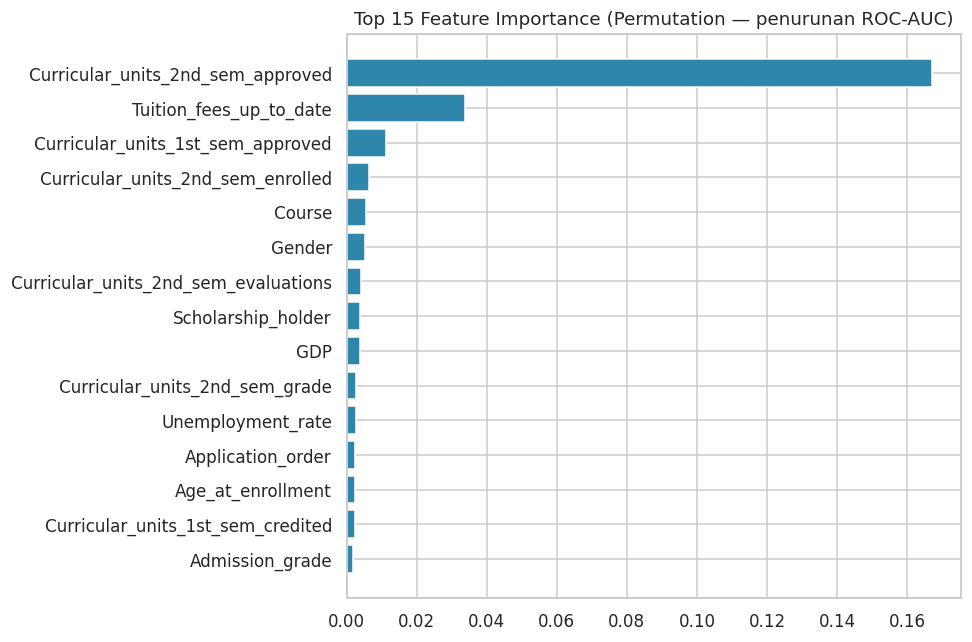

,Fitur,Importance
0,Curricular_units_2nd_sem_approved,0.167085
1,Tuition_fees_up_to_date,0.033788
2,Curricular_units_1st_sem_approved,0.011187
3,Curricular_units_2nd_sem_enrolled,0.006503
4,Course,0.005656
5,Gender,0.005300
6,Curricular_units_2nd_sem_evaluations,0.004028
7,Scholarship_holder,0.003973
8,GDP,0.003880
9,Curricular_units_2nd_sem_grade,0.002786


In [ ]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
importance = (pd.DataFrame({"Fitur": X.columns, "Importance": perm.importances_mean})
              .sort_values("Importance", ascending=False).reset_index(drop=True))

top = importance.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top["Fitur"], top["Importance"], color=PAL[0])
plt.title("Top 15 Feature Importance (Permutation — penurunan ROC-AUC)")
plt.tight_layout(); plt.show()
importance.head(10)

### 6.3 Faktor Penentu Dropout

Hasil *permutation importance* menegaskan temuan EDA:

1. **`Curricular_units_2nd_sem_approved`** — jumlah mata kuliah lulus di semester 2 adalah
   prediktor terkuat, dengan jarak yang sangat lebar dari fitur lainnya.
2. **`Tuition_fees_up_to_date`** — status pelunasan UKT menempati posisi kedua.
3. **`Curricular_units_1st_sem_approved`**, **`Age_at_enrollment`**, **`Course`**, dan
   **`Admission_grade`** melengkapi lima besar berikutnya.

Implikasinya: institusi tidak perlu menunggu hingga akhir masa studi. **Cukup dengan data
akhir semester 2 ditambah status pembayaran, risiko dropout sudah dapat diprediksi secara akurat.**

## 7. Menyimpan Artefak Model

Model final dilatih ulang pada **seluruh data** (latih + uji) agar memanfaatkan semua informasi
yang tersedia, kemudian disimpan bersama nilai threshold dan daftar fitur.

In [ ]:
import os
os.makedirs("model", exist_ok=True)

final_model = Pipeline([("pre", preprocessor), ("clf", models[best_name])])
final_model.fit(X, y)

joblib.dump({"pipeline": final_model, "threshold": round(THRESHOLD, 3),
             "cat": CAT, "num": NUM, "model_name": "HistGradientBoostingClassifier"},
            "model/dropout_model.joblib")

defaults = {c: int(df[c].mode()[0]) for c in CAT}
defaults.update({c: float(df[c].median()) for c in NUM})
json.dump(defaults, open("model/defaults.json", "w"), indent=2)

print("Artefak tersimpan di folder model/")

Artefak tersimpan di folder model/


In [ ]:
# Uji cepat artefak yang tersimpan
bundle = joblib.load("model/dropout_model.joblib")
FEATURES = bundle["cat"] + bundle["num"]

skenario = {
    "Mahasiswa berisiko": {"Curricular_units_1st_sem_approved": 0,
                           "Curricular_units_2nd_sem_approved": 0,
                           "Tuition_fees_up_to_date": 0, "Debtor": 1, "Age_at_enrollment": 30},
    "Mahasiswa aman": {"Curricular_units_1st_sem_approved": 6,
                       "Curricular_units_2nd_sem_approved": 6,
                       "Curricular_units_2nd_sem_grade": 14.0,
                       "Tuition_fees_up_to_date": 1, "Scholarship_holder": 1,
                       "Age_at_enrollment": 19},
}
for nama, nilai in skenario.items():
    frame = pd.DataFrame([{**defaults, **nilai}])[FEATURES]
    p = bundle["pipeline"].predict_proba(frame)[0, 1]
    print(f"{nama:20s} -> skor risiko {p*100:5.1f}%")

Mahasiswa berisiko   -> skor risiko  98.3%
Mahasiswa aman       -> skor risiko   1.8%


## 8. Menyiapkan Dataset untuk Business Dashboard

Kode kategorikal diterjemahkan menjadi label yang dapat dibaca manusia, dan ditambahkan kolom
turunan (`Approval_Rate`, `Kategori_Performa`, `Skor_Risiko`, `Level_Risiko`). Skor risiko dihitung
menggunakan **prediksi out-of-fold** agar nilainya jujur (tidak *overfit* pada data yang sama).

In [ ]:
MARITAL = {1: "Single", 2: "Married", 3: "Widower", 4: "Divorced",
           5: "Facto Union", 6: "Legally Separated"}
APPMODE = {1: "1st phase - general", 2: "Ordinance 612/93", 5: "1st phase - Azores",
           7: "Holder of other higher course", 10: "Ordinance 854-B/99",
           15: "International student", 16: "1st phase - Madeira", 17: "2nd phase - general",
           18: "3rd phase - general", 26: "Different Plan", 27: "Other Institution",
           39: "Over 23 years old", 42: "Transfer", 43: "Change of course",
           44: "Tech. specialization holder", 51: "Change of institution/course",
           53: "Short cycle holder", 57: "Change of institution (Intl)"}

risk = cross_val_predict(Pipeline([("pre", preprocessor), ("clf", models[best_name])]),
                         X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

d = df.copy()
d.insert(0, "Student_ID", ["STD-" + str(i).zfill(4) for i in range(1, len(d) + 1)])
d["Jalur_Masuk"] = d["Application_mode"].map(APPMODE).fillna("Lainnya")
d["Status_Pernikahan"] = d["Marital_status"].map(MARITAL).fillna("Lainnya")
d["Gender_Label"] = d["Gender"].map({1: "Laki-laki", 0: "Perempuan"})
d["Kelas"] = d["Daytime_evening_attendance"].map({1: "Reguler (Siang)", 0: "Kelas Malam"})
for c, lab in [("Debtor", ("Tidak", "Ya")), ("Tuition_fees_up_to_date", ("Menunggak", "Lunas")),
               ("Scholarship_holder", ("Tidak", "Ya")), ("Displaced", ("Tidak", "Ya")),
               ("Educational_special_needs", ("Tidak", "Ya")),
               ("International", ("Domestik", "Internasional"))]:
    d[c + "_Label"] = d[c].map({0: lab[0], 1: lab[1]})
d["Kelompok_Usia"] = pd.cut(d["Age_at_enrollment"], [0, 20, 23, 27, 35, 100],
                            labels=["<=20", "21-23", "24-27", "28-35", ">35"])
d["Rata_Nilai"] = ((d["Curricular_units_1st_sem_grade"] +
                    d["Curricular_units_2nd_sem_grade"]) / 2).round(2)
d["Approval_Rate"] = d["Approval_Rate"].round(1)
d["Is_Dropout"] = d["Dropout"]
d["Skor_Risiko"] = (risk * 100).round(1)
d["Level_Risiko"] = pd.cut(d["Skor_Risiko"], [-1, 30, 60, 100],
                           labels=["Rendah", "Sedang", "Tinggi"])

keep = ["Student_ID", "Status", "Is_Dropout", "Skor_Risiko", "Level_Risiko", "Program_Studi",
        "Jalur_Masuk", "Kelas", "Gender_Label", "Kelompok_Usia", "Age_at_enrollment",
        "Status_Pernikahan", "Debtor_Label", "Tuition_fees_up_to_date_Label",
        "Scholarship_holder_Label", "Displaced_Label", "Educational_special_needs_Label",
        "International_Label", "Admission_grade", "Previous_qualification_grade",
        "Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
        "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_enrolled",
        "Curricular_units_2nd_sem_approved", "Curricular_units_2nd_sem_grade",
        "Approval_Rate", "Rata_Nilai", "Kategori_Performa",
        "Unemployment_rate", "Inflation_rate", "GDP"]

os.makedirs("dashboard", exist_ok=True)
dash = d[keep]
dash.to_csv("dashboard/students_dashboard.csv", index=False)
print("Dimensi dataset dashboard:", dash.shape)
dash.head()

Dimensi dataset dashboard: (4424, 32)


,Student_ID,Status,Is_Dropout,Skor_Risiko,Level_Risiko,Program_Studi,Jalur_Masuk,Kelas,Gender_Label,Kelompok_Usia,...,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Approval_Rate,Rata_Nilai,Kategori_Performa,Unemployment_rate,Inflation_rate,GDP
0,STD-0001,Dropout,1,61.7,Tinggi,Animation & Multimedia,2nd phase - general,Reguler (Siang),Laki-laki,<=20,...,0.000000,0,0,0.000000,0.0,0.00,Kritis (<25%),10.8,1.4,1.74
1,STD-0002,Graduate,0,7.0,Rendah,Tourism,International student,Reguler (Siang),Laki-laki,<=20,...,14.000000,6,6,13.666667,100.0,13.83,Baik (>75%),13.9,-0.3,0.79
2,STD-0003,Dropout,1,97.8,Tinggi,Communication Design,1st phase - general,Reguler (Siang),Laki-laki,<=20,...,0.000000,6,0,0.000000,0.0,0.00,Kritis (<25%),10.8,1.4,1.74
3,STD-0004,Graduate,0,6.5,Rendah,Journalism & Comm,2nd phase - general,Reguler (Siang),Perempuan,<=20,...,13.428571,6,5,12.400000,91.7,12.91,Baik (>75%),9.4,-0.8,-3.12
4,STD-0005,Graduate,0,7.7,Rendah,Social Service (eve),Over 23 years old,Kelas Malam,Perempuan,>35,...,12.333333,6,6,13.000000,91.7,12.67,Baik (>75%),13.9,-0.3,0.79


In [ ]:
# Validasi kalibrasi level risiko
cek = dash.groupby("Level_Risiko", observed=True)["Is_Dropout"].agg(
    Jumlah_Mahasiswa="count", Dropout_Rate_Aktual="mean")
cek["Dropout_Rate_Aktual"] = (cek["Dropout_Rate_Aktual"] * 100).round(1)
cek

,Jumlah_Mahasiswa,Dropout_Rate_Aktual
Level_Risiko,,
Rendah,2889,8.8
Sedang,438,40.2
Tinggi,1097,90.2


**Validasi.** Level risiko yang dihasilkan model terkalibrasi dengan baik: kelompok **Risiko
Tinggi** memiliki dropout rate aktual **90,2%**, **Sedang 40,2%**, dan **Rendah 8,8%**. Dengan
demikian daftar prioritas yang muncul di dashboard benar-benar dapat dipercaya oleh bagian
kemahasiswaan.

## 9. Conclusion

Proyek ini berhasil menjawab keempat permasalahan bisnis Jaya Jaya Institut.

**1. Besaran dan sebaran masalah.** Sebanyak **32,1%** dari 4.424 mahasiswa berstatus dropout —
hampir sepertiga populasi, jauh di atas batas wajar. Masalah ini terkonsentrasi pada program studi
tertentu: **Biofuel Production Technologies (66,7%)**, **Equinculture (55,3%)**, **Informatics
Engineering (54,1%)**, dan **Management kelas malam (50,7%)**.

**2. Faktor penentu dropout.** Analisis EDA dan permutation importance secara konsisten menunjuk
dua kelompok faktor dominan:

- **Performa akademik dua semester pertama.** Jumlah mata kuliah yang lulus di semester 2 adalah
  prediktor tunggal terkuat. Mahasiswa dengan tingkat kelulusan mata kuliah di bawah 25% memiliki
  dropout rate **81,6%**, sementara yang di atas 75% hanya **8,2%**.
- **Kondisi finansial.** Mahasiswa yang menunggak UKT dropout pada tingkat **86,6%** (vs 24,7% yang
  lunas), dan berstatus debitur pada tingkat **62,0%**. Sebaliknya penerima beasiswa jauh lebih
  aman (**12,2%**).

Menariknya, **nilai ujian masuk hampir tidak membedakan** kelompok dropout dan lulusan. Artinya
dropout di Jaya Jaya Institut bukan masalah seleksi calon mahasiswa, melainkan masalah **dukungan
selama masa studi** — terutama dukungan finansial dan pendampingan akademik.

**3. Sistem deteksi dini.** Model **HistGradientBoostingClassifier** mencapai **ROC-AUC 0,934**,
**akurasi 89,7%**, dan **recall 79,9%** pada data uji. Artinya sistem mampu menangkap **8 dari 10
calon dropout** dengan presisi 87% — cukup andal untuk dijadikan dasar penentuan prioritas
bimbingan. Karena prediktor utamanya adalah data akhir semester 2, deteksi dapat dilakukan
**sejak tahun pertama**, memberi institusi waktu intervensi yang memadai.

**4. Alat monitoring.** Business dashboard dan prototype Streamlit telah dibangun sehingga
manajemen dapat memantau performa siswa dan menghasilkan daftar prioritas intervensi secara
mandiri, tanpa perlu menjalankan kode.

**Estimasi dampak.** Dengan recall 79,9% terhadap 1.421 mahasiswa dropout, sistem ini dapat
mengidentifikasi sekitar **1.135 mahasiswa berisiko** untuk diintervensi lebih awal. Bila program
bimbingan berhasil menyelamatkan 30% saja di antaranya, institusi mempertahankan sekitar **340
mahasiswa** — setara penurunan dropout rate dari 32,1% menjadi sekitar **24,4%**.

## 10. Rekomendasi Action Items

**1. Terapkan sistem deteksi dini di akhir setiap semester.**
Jalankan prediksi massal pada seluruh mahasiswa aktif setiap akhir semester menggunakan prototype
Streamlit, lalu terbitkan daftar prioritas berdasarkan skor risiko. Mahasiswa dengan skor ≥ 60
(Risiko Tinggi) wajib masuk program bimbingan khusus dalam dua minggu pertama semester berikutnya.

**2. Bentuk skema keringanan biaya sebagai intervensi prioritas.**
Karena tunggakan UKT adalah prediktor terkuat kedua (dropout rate 86,6%), sediakan skema cicilan
fleksibel, penundaan pembayaran, atau dana talangan darurat. Kontak proaktif — jangan menunggu
mahasiswa mengajukan — kepada setiap mahasiswa yang tunggakannya melewati 30 hari.

**3. Perluas dan targetkan ulang alokasi beasiswa.**
Penerima beasiswa hanya dropout 12,2% dibanding 38,7% pada non-penerima. Prioritaskan alokasi
beasiswa bagi mahasiswa berskor risiko tinggi namun berpotensi akademik, dan pertimbangkan
menaikkan kuota untuk program studi dengan dropout rate tertinggi.

**4. Terapkan aturan pemicu akademik otomatis (academic trigger).**
Tetapkan aturan sederhana yang dapat dijalankan dosen wali tanpa model: mahasiswa dengan tingkat
kelulusan mata kuliah **< 50%** pada semester berjalan otomatis dijadwalkan konseling akademik,
remedial, dan peninjauan beban SKS semester berikutnya.

**5. Audit program studi berisiko tinggi.**
Lakukan evaluasi kurikulum, beban studi, dan kualitas pengajaran pada Biofuel Production
Technologies, Equinculture, Informatics Engineering, dan Management kelas malam. Dropout rate di
atas 50% mengindikasikan masalah struktural pada program, bukan sekadar masalah individu mahasiswa.

**6. Rancang dukungan khusus mahasiswa non-tradisional.**
Mahasiswa yang mendaftar pada usia di atas 25 tahun, masuk lewat jalur "Over 23 years old", atau
mengambil kelas malam berisiko lebih tinggi. Sediakan kelas hybrid, jadwal fleksibel, dan
pendampingan manajemen waktu untuk kelompok ini.

**7. Pantau dashboard secara berkala dan perbarui model setiap tahun.**
Tetapkan rapat evaluasi bulanan berbasis dashboard, dengan indikator utama berupa jumlah mahasiswa
Risiko Tinggi, dropout rate per program studi, dan proporsi tunggakan UKT. Latih ulang model setiap
tahun ajaran menggunakan data terbaru agar performa tetap terjaga.